## Data 622 
### Assignment 4

### **Business Goals/Proposal:**

    1) As lending is the primary source of income for commercial banks, accurate credit risk assessment is paramount. Poor assessment directly leads to increased Non-Performing Loans (NPLs) and loan losses, which erode capital reserves and threaten institutional stability.

    2) We propose to build, compare, and fine-tune different supervised ML models—such as RandomForest, XGBoosting, and PyTorch Neural Network—to accurately assess credit risk. The output will determine whether a loan application is approved or rejected based on the client's background.

### Models tested:

    1)RandomForest
    2)XGBoost
    3)PyTorch Neural Network

This is a synthetic data created on Kaggle for a ML competition.

Data source: https://www.kaggle.com/competitions/playground-series-s5e11

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import randint
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

## 1) Reading into dataframes for both train and test set

In [2]:
df_train = pd.read_csv(r'G:\My Drive\CUNY SPS\class materials\Fall 2025\622\Assignment 4\loan_payback_df\train.csv')

df_train.head()


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


## 2) Basic information about this dataset:

In [3]:
print('Display basic information about the training dataset:')
df_train.info()
df_train.describe()

print('-'*80)
print('Check for missing values')
print(df_train.isnull().sum())
print('-'*80)
print('Data dimensions:')
print(f'Num of rows: {df_train.shape[0]}\nNum of columns: {df_train.shape[1]}')

Display basic information about the training dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 5

## 3) EDA for the dataset:

What are the distribution of the data between people who will payback their loans?

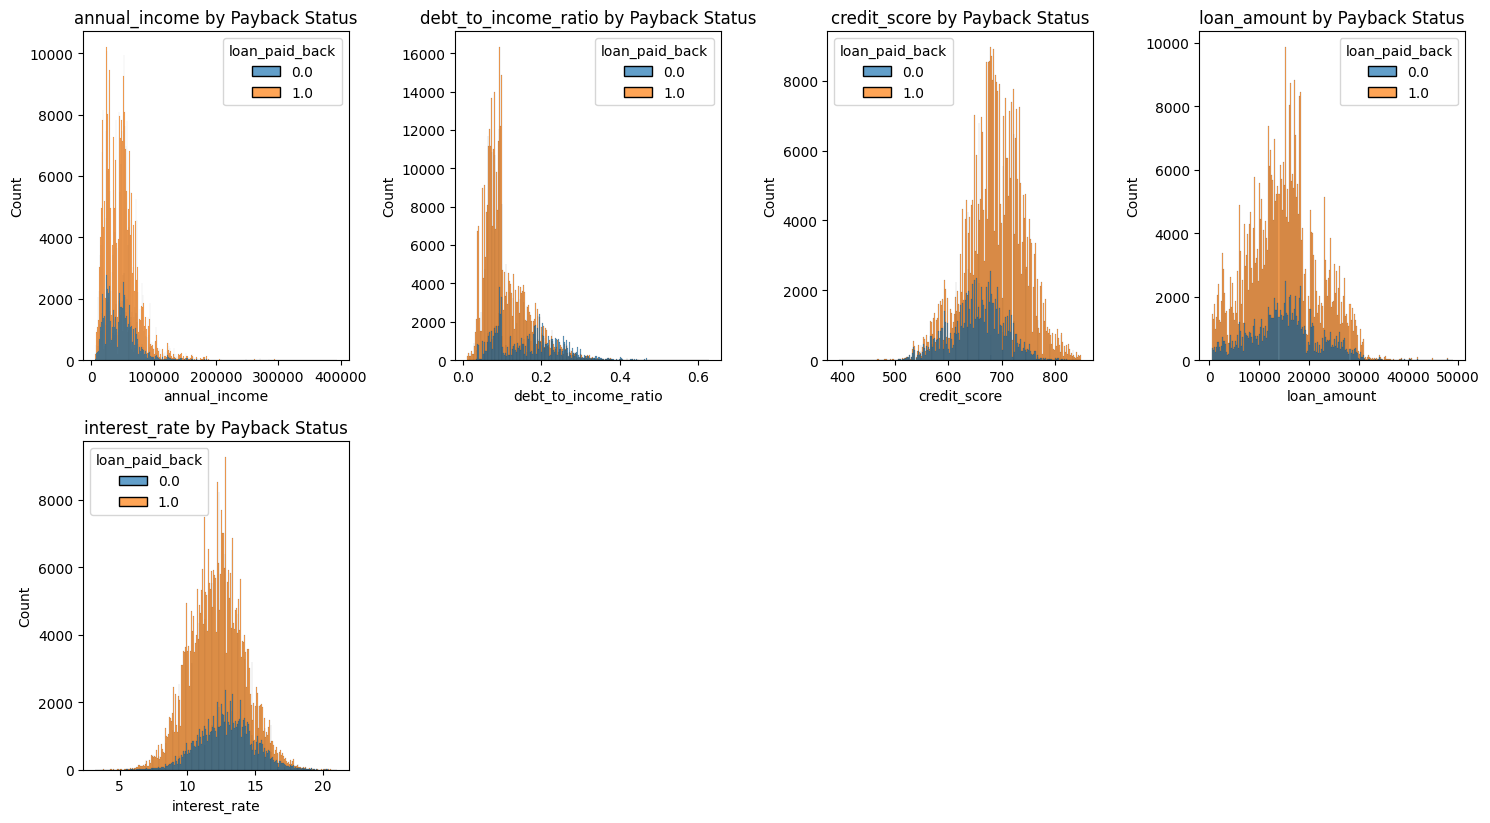

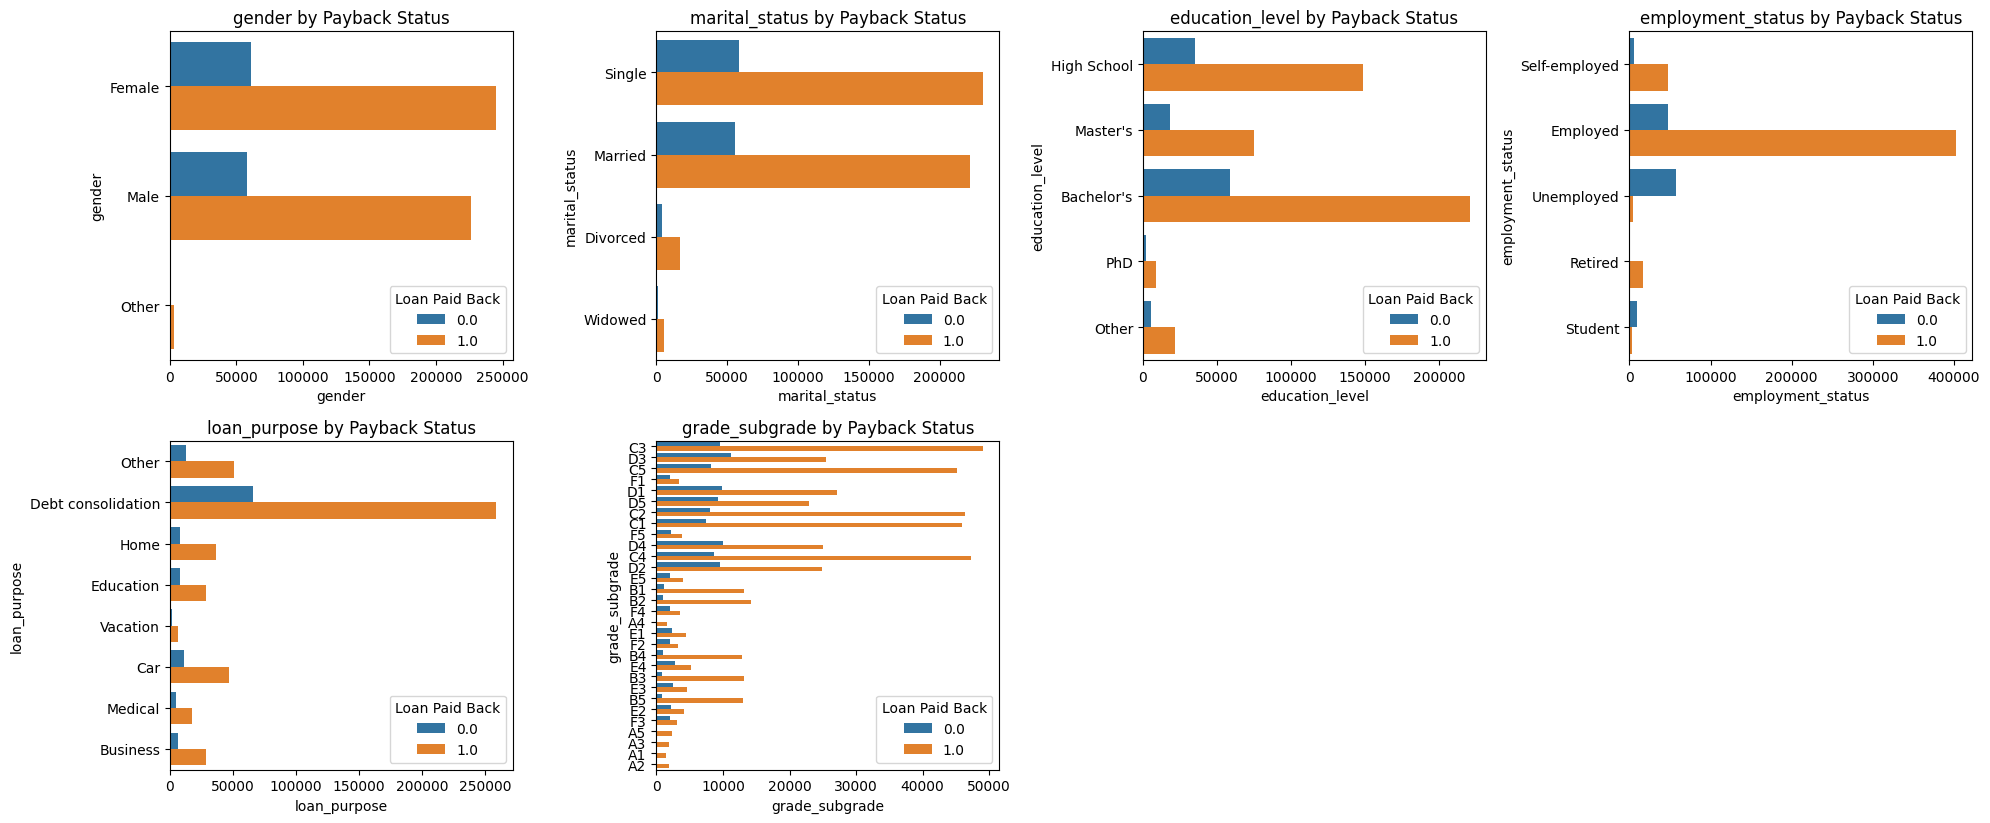

In [4]:
#Separate the columns into features and target variable:
X = df_train.drop(['loan_paid_back', 'id'], axis = 1) #Drop the id column and the target variable
y = df_train['loan_paid_back']

#Separate numerical and categorical columns:
cat_col = X.select_dtypes(include = 'object').columns
num_col = X.select_dtypes(include = ['int64', 'float64']).columns


#Visualize the distribution of numerical features based on the target variable:

num_plots = len(num_col)
num_cols_in_grid = 2
num_row = (num_plots + 1) // num_cols_in_grid
plt.figure(figsize=(15,4 * num_row))
for i, col in enumerate(num_col):
    plt.subplot(3, 4, i+1)
    sns.histplot(df_train,
                x = col,
                hue = 'loan_paid_back',
                alpha = 0.7       
                 )
    plt.title(f'{col} by Payback Status')
    plt.xlabel(col)
    plt.tight_layout()

plt.figure(figsize=(20,4 * num_row))
for j, col in enumerate(cat_col):
    plt.subplot(3, 4, j+1)
    sns.countplot(data=df_train, y=col, hue='loan_paid_back')
    plt.title(f'{col} by Payback Status')
    plt.xlabel(col)
    plt.legend(title='Loan Paid Back', loc='lower right')
    plt.tight_layout()


Few key points from the EDA:
1) Two ordinal categories are identified: Education level and Grade_subgrade, which is risk category for loan payback.
2) The dataset is imbalanced to favor paybacks. We might need to resample the dataset to re-balance the target variables.
3) People with employments are more likely to payback their loans.
4) People with bacholar degree is more likely to payback their loans, implying more likely to get a loan as well.

### Explore potential outliers:

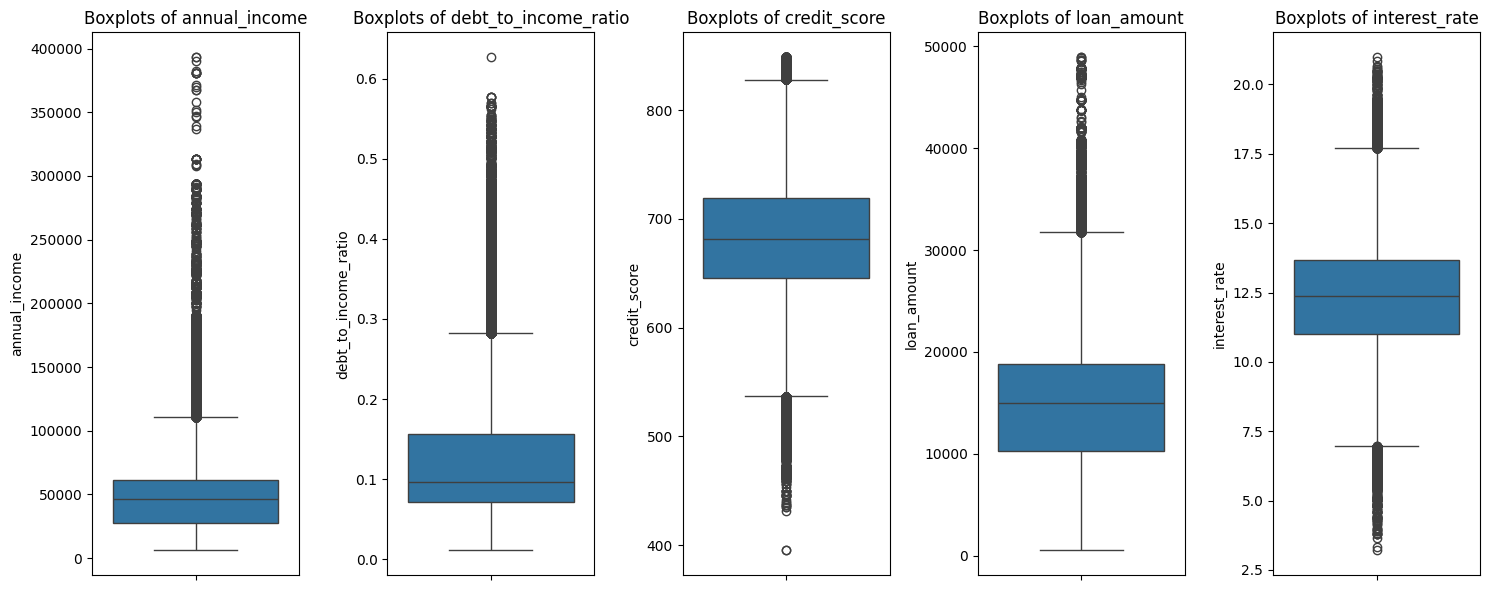

In [5]:
plt.figure(figsize=(15,6))
for i, col in enumerate(num_col):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y= df_train[col])
    plt.title(f'Boxplots of {col}')
    plt.tight_layout()

In [6]:
#calculate the outliers:
for col in num_col:
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
    outlier_percentage = (outliers.shape[0] / df_train.shape[0]) * 100
    print(f'Outliers in {col}: {outliers.shape[0]} ({outlier_percentage:.2f}%)')

Outliers in annual_income: 15917 (2.68%)
Outliers in debt_to_income_ratio: 17556 (2.96%)
Outliers in credit_score: 5901 (0.99%)
Outliers in loan_amount: 2902 (0.49%)
Outliers in interest_rate: 5136 (0.86%)


While the outliers are between 0.5% ~ 3%, we should use capping method to retain data.

We will set the lower and upper bound as the min and max for the outliers.

In [7]:
#We will calculate the frequncy of each category class:
for col in cat_col:
    print(f'Percentage of each class in {col}:')
    print((df_train[col].value_counts()/len(df_train) * 100).round(2))
    print('-'*40)    

Percentage of each class in gender:
gender
Female    51.55
Male      47.83
Other      0.63
Name: count, dtype: float64
----------------------------------------
Percentage of each class in marital_status:
marital_status
Single      48.63
Married     46.67
Divorced     3.59
Widowed      1.11
Name: count, dtype: float64
----------------------------------------
Percentage of each class in education_level:
education_level
Bachelor's     47.07
High School    30.91
Master's       15.67
Other           4.49
PhD             1.86
Name: count, dtype: float64
----------------------------------------
Percentage of each class in employment_status:
employment_status
Employed         75.87
Unemployed       10.52
Self-employed     8.84
Retired           2.77
Student           2.01
Name: count, dtype: float64
----------------------------------------
Percentage of each class in loan_purpose:
loan_purpose
Debt consolidation    54.66
Other                 10.75
Car                    9.78
Home             

We can group  Gender class 'Other' and Martial status 'Widowed' as 'Rare' since they are less than 1.5%

## 4) Data Engineering/Cleaning:

### Train Split the data:

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_training size: {X_train.shape}')
print(f'X_test size: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

X_training size: (475195, 11)
X_test size: (118799, 11)
y_train: (475195,)
y_test: (118799,)


### Capping the outliers

In [9]:
#To cap the outliers to either upper or lower bound:
for col in num_col:
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)
    #Applying the soft-capping to the test set as well:
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound) #Applying the learned bounds from training set to test set
    
#To verify the outliers have been capped:
for col in num_col:
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]
    outlier_percentage = (outliers.shape[0] / X_train.shape[0]) * 100
    print(f'Outliers in {col} after capping: {outliers.shape[0]} ({outlier_percentage:.2f}%)')

    

Outliers in annual_income after capping: 0 (0.00%)
Outliers in debt_to_income_ratio after capping: 0 (0.00%)
Outliers in credit_score after capping: 0 (0.00%)
Outliers in loan_amount after capping: 0 (0.00%)
Outliers in interest_rate after capping: 0 (0.00%)


### Grouping the low frequency classes into 'Rare' group:

In [10]:
low_freq_label = 'Rare'
low_freq_threshold = 0.015

#Define a transformation function to group low frequency classes from training set only:
def group_rare(df, col, threshold):
    value_count = df[col].value_counts(normalize=True)
    rare_labels = value_count[value_count < threshold].index.tolist()
    return rare_labels

def apply_label(df, col, rare_labels, new_label):
    df[col] = df[col].replace(rare_labels, new_label)
    return df

#This is needed to ensure that th rare labels from the training set are applied to both training and test sets:
gender_rare = group_rare(X_train, 'gender', low_freq_threshold)
marital_rare = group_rare(X_train, 'marital_status', low_freq_threshold)

X_train = apply_label(X_train, 'gender', gender_rare, low_freq_label)
X_train = apply_label(X_train, 'marital_status', marital_rare, low_freq_label)

#Apply the same transformation to the test set:
X_test = apply_label(X_test, 'gender', gender_rare, low_freq_label)
X_test = apply_label(X_test, 'marital_status', marital_rare, low_freq_label)

### Ordinal and nomial encoding for 'education level' and 'grade subgrade':
#### These two has obvious ordinal relationships between them. OneHotEncoding is not appropriate.

In [11]:
#We will work on educational level first since it needs ordinal encoding and onehot encoding for the 'other' category.
education_order = ['High School', 'Bachelor\'s', 'Master\'s', 'PhD'] #Define the orders
ed_category = [education_order]
oe = OrdinalEncoder(categories = ed_category, handle_unknown='use_encoded_value', unknown_value=-1)

#Filter out the 'Other' category for onehot encoding later:
df_ordinal_fit = X_train[X_train['education_level'] != 'Other']

oe.fit(df_ordinal_fit[['education_level']])

X_train['education_ordinal'] = oe.transform(X_train[['education_level']])

#Create a separate column for 'Other' category:
X_train['education_other'] = X_train['education_level'].apply(lambda x: 1 if x =='Other' else 0)

#Drop the original education_level column:
X_train = X_train.drop('education_level', axis=1)

#Apply the same transformation to the test set:
X_test['education_ordinal'] = oe.transform(X_test[['education_level']])
X_test['education_other'] = X_test['education_level'].apply(lambda x: 1 if x =='Other' else 0)
X_test = X_test.drop('education_level', axis=1)

In [12]:
#Create another ordinal encoder for grade_subgrade column:
grade_order = ['A1', 'A2', 'A3', 'A4', 'A5',
               'B1', 'B2', 'B3', 'B4', 'B5',
               'C1', 'C2', 'C3', 'C4', 'C5',
               'D1', 'D2', 'D3', 'D4', 'D5',
               'E1', 'E2', 'E3', 'E4', 'E5',
               'F1', 'F2', 'F3', 'F4', 'F5',
               'G1', 'G2', 'G3', 'G4', 'G5']

grade_category = [grade_order]
oe_grade = OrdinalEncoder(categories = grade_category)
oe_grade.fit(X_train[['grade_subgrade']])
X_train['grade_ordinal'] = oe_grade.transform(X_train[['grade_subgrade']])
#Drop the original grade_subgrade column:
X_train = X_train.drop('grade_subgrade', axis=1)

#Apply the same transformation to the test set:
X_test['grade_ordinal'] = oe_grade.transform(X_test[['grade_subgrade']])
X_test = X_test.drop('grade_subgrade', axis=1)


### OneHotEncoding for the remaining categorical variables:

In [13]:
#OneHotEncoding for the remaining categorical variables:
cat_col = X_train.select_dtypes(include='object').columns
num_col = X_train.select_dtypes(include=['int64', 'float64']).columns

#Create preprocessor for onehot encoding:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_col),
        ('num', 'passthrough', num_col)], remainder='passthrough'
)

#Fit and transform the training data:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Apply SMOTE to balance the dataset:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

print(f"SMOTE applied. New X_train shape: {X_train_res.shape}")
print(f"New y_train counts: {y_train_res.value_counts()}")

SMOTE applied. New X_train shape: (759190, 28)
New y_train counts: loan_paid_back
1.0    379595
0.0    379595
Name: count, dtype: int64


## 5) Model building:

### RandomForest model:

In [14]:
#Tune and build the RandomForest model:
rf = RandomForestClassifier(random_state=41, n_jobs=-1, class_weight='balanced')
pipeline = Pipeline([('rf', rf)])

param_grid = {
    'rf__n_estimators': randint(100, 700),
    'rf__max_depth': [10, 20]}

random_grid = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=5, cv=2,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
    )

random_grid.fit(X_train_res, y_train_res)
y_pred = random_grid.predict(X_test_processed)


print('Best parameters:', random_grid.best_params_)
print('-'*80)
print(f'Best training score/test score: {random_grid.best_score_:.2f}/{random_grid.score(X_test_processed, y_test):.2f}')
print('-'*80)
print(classification_report(y_test, y_pred))
    

Best parameters: {'rf__max_depth': 10, 'rf__n_estimators': 370}
--------------------------------------------------------------------------------
Best training score/test score: 0.91/0.81
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.92      0.55      0.69     23900
         1.0       0.90      0.99      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.91      0.77      0.81    118799
weighted avg       0.90      0.90      0.89    118799



### We can fine the threshold for RandomForest so that the recall and precision is more balanced:
#### We will re-define the rf model without SMOTE or class weight to get the baseline

In [15]:
rf_base = RandomForestClassifier(
    n_estimators = 370,
    max_depth = 10,
    random_state=42
)
rf_base.fit(X_train_processed, y_train)
y_proba_rf = rf_base.predict_proba(X_test_processed)[:, 1]

threshold_range = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
print(f"{'RF Threshold':<15} {'Recall (Default)':<20} {'Precision (Default)':<20}")
print("-" * 60)

for thresh in threshold_range:
    y_pred_rf = (y_proba_rf > thresh).astype(int)
    
    report = classification_report(y_test, y_pred_rf, output_dict=True)
    try:
        rec_0 = report['0']['recall']
        prec_0 = report['0']['precision']
    except KeyError:
        rec_0 = report['0.0']['recall']
        prec_0 = report['0.0']['precision']
    
    print(f'{thresh:<15} {rec_0:<20.2f} {prec_0:<20.2f}')
print("-" * 60)

RF Threshold    Recall (Default)     Precision (Default) 
------------------------------------------------------------
0.5             0.55                 0.93                
0.55            0.57                 0.90                
0.6             0.61                 0.85                
0.65            0.67                 0.79                
0.7             0.70                 0.74                
0.75            0.73                 0.71                
0.8             0.77                 0.64                
------------------------------------------------------------


Threshold of **0.75** gives the best balance between recall and precision for the rf model:

In [16]:
#We will apply it as the final model threshold:
y_proba_rf = rf_base.predict_proba(X_test_processed)[:, 1]
y_pred_rf_optimzed = (y_proba_rf > 0.75).astype(int)

# 3. Verify the final report
print("--- Random Forest (Optimized @ 0.75) ---")
print(classification_report(y_test, y_pred_rf_optimzed))

--- Random Forest (Optimized @ 0.75) ---
              precision    recall  f1-score   support

         0.0       0.71      0.73      0.72     23900
         1.0       0.93      0.92      0.93     94899

    accuracy                           0.88    118799
   macro avg       0.82      0.82      0.82    118799
weighted avg       0.89      0.88      0.88    118799



### XGB with CUDA processor:

Since native XGB model can handle imbalance data better than SMOTE, we will compute the imbalance ratio manually

In [17]:
import xgboost as xgb

#Define pos and neg ratio:
n_pos = sum(y_train == 1)
n_neg = sum(y_train == 0)
scale_weight = n_neg / n_pos

print(f"Positive: {n_pos}, Negative: {n_neg}")
print(f"Recommended scale_pos_weight: {scale_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=5000,
    tree_method='hist',
    device='cuda',
    eval_metric = 'auc',
    learning_rate=0.01,
    scale_pos_weight=scale_weight,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test_processed)


print(classification_report(y_test, y_pred_xgb))

Positive: 379595, Negative: 95600
Recommended scale_pos_weight: 0.25
              precision    recall  f1-score   support

         0.0       0.64      0.79      0.71     23900
         1.0       0.94      0.89      0.92     94899

    accuracy                           0.87    118799
   macro avg       0.79      0.84      0.81    118799
weighted avg       0.88      0.87      0.87    118799



C:\Users\godly\AppData\Roaming\Python\Python314\site-packages\xgboost\core.py:774: UserWarning: [12:53:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


### We can find the threshold of XGB so that the recall and precision is more balanced:
#### We will re-define the XGB model without SMOTE or class weight to get the baseline

In [18]:
#Set up a baseline xgb model without weight:
xgb_model_base = xgb.XGBClassifier(
    n_estimators=5000,
    tree_method='hist',
    device='cuda',
    eval_metric = 'auc',
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50
)

xgb_model_base.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)], verbose=False)

y_prob_pay = xgb_model_base.predict_proba(X_test_processed)[:, 1]

#Define different thresholds:
thresholds = [0.5, 0.6, 0.7, 0.8]
print(f"{'Threshold':<10} {'Recall (Default)':<20} {'Precision (Default)':<20}")
print("-" * 80)

for thresh in thresholds:
    y_pred_custom = (y_prob_pay > thresh).astype(int)
    report = classification_report(y_test, y_pred_custom, output_dict=True)
    
    rec_0 = report['0.0']['recall']
    prec_0 = report['0.0']['precision']
    
    print(f"{thresh:<10} {rec_0:<20.2f} {prec_0:<20.2f}")

print("-" * 80)

Threshold  Recall (Default)     Precision (Default) 
--------------------------------------------------------------------------------
0.5        0.60                 0.88                
0.6        0.66                 0.81                
0.7        0.73                 0.73                
0.8        0.80                 0.63                
--------------------------------------------------------------------------------


A threshold of 0.7 is the balanced spot for both recall and precision for predicting 0 class, loan default.

### Applying a 0.7 threshold for XGB model:

In [19]:
y_prob_xgb = xgb_model_base.predict_proba(X_test_processed)[:, 1]
y_pred_xgb_optimized = (y_prob_xgb > 0.7).astype(int)
print(classification_report(y_test, y_pred_xgb_optimized))

              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73     23900
         1.0       0.93      0.93      0.93     94899

    accuracy                           0.89    118799
   macro avg       0.83      0.83      0.83    118799
weighted avg       0.89      0.89      0.89    118799



### Pytorch model:

In [20]:
#Ensures that GPU is enabled:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [21]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
from loader import FastTensorDataLoader

In [22]:
#Center the data for pytorch model:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)


#Convert datainto tensors:
X_train_tensor = torch.from_numpy(X_train_scaled).float().to(device)
X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
y_train_tensor = torch.from_numpy(y_train.values).float().view(-1, 1).to(device)
y_test_tensor = torch.from_numpy(y_test.values).float().view(-1, 1).to(device)

#Create TensorDataset:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

Batch_size = 32768 #Using RTX3080
#A custom Dataloader is used here for tabular dataset to speed up the process:
#Create dataloader:
train_loader = FastTensorDataLoader(X_train_tensor, y_train_tensor, batch_size=Batch_size, shuffle=True)
test_loader = FastTensorDataLoader(X_test_tensor, y_test_tensor, batch_size=Batch_size, shuffle=False)



### Building the PyTorch NN:

In [23]:
input_size = X_train_tensor.shape[1]
output_size = 1

class loanNN(nn.Module):
    def __init__(self, input_dim):
        super(loanNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 160)
        self.fc2 = nn.Linear(160, 32)
        self.fc3 = nn.Linear(32, output_size)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = loanNN(input_dim=input_size)
model.to(device)

print(model)

loanNN(
  (fc1): Linear(in_features=28, out_features=160, bias=True)
  (fc2): Linear(in_features=160, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


### Define loss function and optimizer:

In [24]:
criterion = nn.BCEWithLogitsLoss()

learn_rate = 0.01
optimizer = optim.Adam(model.parameters(), lr=learn_rate)

### Define the training loop for backpropagation:

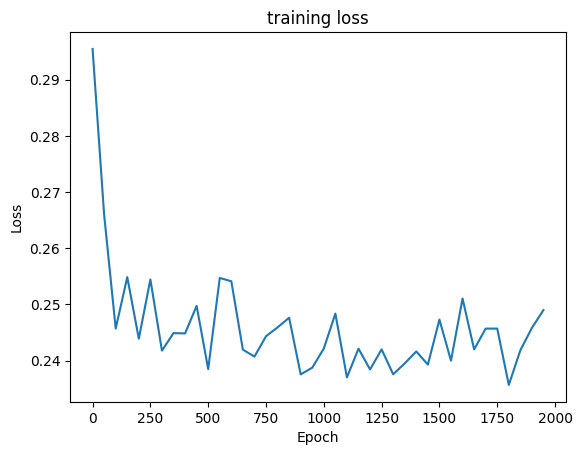

In [25]:
num_epoch = 2000

loss_plot = []
epoch_num = []

for epoch in range(num_epoch):
    model.train()
    for inputs, targets in train_loader:
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
           
    if epoch %50 == 0:
        loss_plot.append(loss.item())
        epoch_num.append(epoch)

plt.plot(range(0, num_epoch, 50), loss_plot)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('training loss')
plt.show()

Looks like the initial weight and bias are already very solid and additional epoch does not improve much.

### We will apply the same threshold for NN as in XGB:

In [26]:
#Threshold:
threshold = 0.7

model.eval()

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    correct = 0
    total = 0
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicted_probs = torch.sigmoid(outputs)
        predicted = (predicted_probs > threshold).float()
        
        all_preds.append(predicted)
        all_targets.append(targets)
        all_probs.append(predicted_probs)
                
        
all_preds_tensor = torch.cat(all_preds)
all_targets_tensor = torch.cat(all_targets)
all_probs_tensor = torch.cat(all_probs)

preds_cpu = all_preds_tensor.cpu().numpy()
targets_cpu = all_targets_tensor.cpu().numpy()
probs_cpu = all_probs_tensor.cpu().numpy()

print(classification_report(targets_cpu, preds_cpu))


              precision    recall  f1-score   support

         0.0       0.69      0.71      0.70     23900
         1.0       0.93      0.92      0.92     94899

    accuracy                           0.88    118799
   macro avg       0.81      0.82      0.81    118799
weighted avg       0.88      0.88      0.88    118799



## Summary ROC-AUC plot:

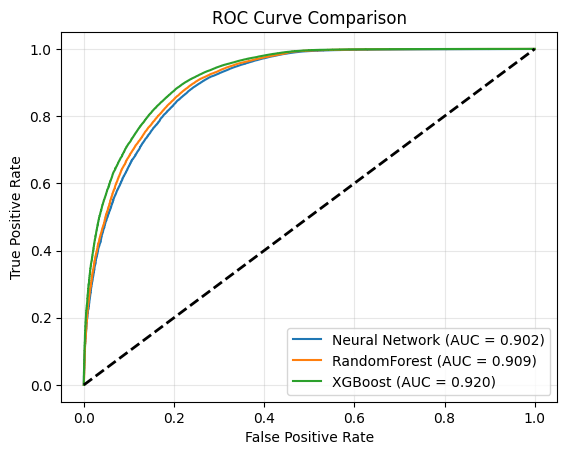

In [27]:
y_prob_rf = random_grid.predict_proba(X_test_processed)[:, 1]
y_prob_xgb = xgb_model_base.predict_proba(X_test_processed)[:, 1]
y_prob_NN = probs_cpu

from sklearn.metrics import roc_curve, auc
fpr_nn, tpr_nn, _ = roc_curve(targets_cpu, y_prob_NN)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_nn = auc(fpr_nn, tpr_nn)

plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')

#Random guess line:
plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Concusion:

The ability to accurately predict client loan default is a cornerstone of financial stability for commercial institutions. This study focused on developing and comparing robust Machine Learning (ML) models to predict whether clients would default on or repay a loan, leveraging their background information.

Our analysis utilized a substantial dataset of approximately 590,000 rows. Despite having no missing values, the data presented common challenges inherent in financial risk modeling: the presence of outliers, rare categorical groups that could skew predictions, and a heavily imbalanced target variable favoring the non-default class. To address these issues and ensure model reliability, we implemented a comprehensive preprocessing pipeline. Key strategies included outlier capping, various forms of feature encoding (ordinal and One-Hot Encoding), SMOTE for synthetic minority oversampling, class weight assignment, and post-training threshold tuning to optimize for the minority class.

Three distinct models were built and rigorously compared: RandomForest, XGBoost, and a PyTorch Neural Network (NN). Beyond predictive performance, a critical component of our evaluation was computational efficiency, recognizing that training on datasets potentially exceeding one million samples requires optimized resource utilization. We explicitly tested the CPU-bound RandomForest against the GPU/CUDA-core utilizing XGBoost and PyTorch NN.The results clearly favored the XGBoost model, which demonstrated the best predictive performance coupled with the least computational time. After threshold tuning, XGBoost achieved an F1-macro score of 0.83 and an AUC score of 0.92. Critically, both recall and precision for the minority class (default clients) reached 0.73. This represents a notable gain: the XGBoost model was 2% more sensitive at identifying potential defaulters than the PyTorch NN (recall of $0.71$).In terms of speed, the XGBoost model with CUDA processing was generated in only ~16 seconds. While the PyTorch NN took $31$ seconds (using 2,000 epochs), both methods demonstrated a significant advantage over the traditional, CPU-reliant RandomForest algorithm, proving that scalability for larger datasets is feasible using GPU-optimized architectures.

The performance differences observed, though seemingly minor in metrics, translate into substantial financial impact. The 2% gain in recall achieved by the XGBoost model, when applied to a commercial portfolio of 500,000 loan applicants, allows the institution to avoid an additional 10,000 cases of loan default. This increased accuracy in identifying and mitigating high-risk applicants equates to an avoidance of approximately $200 million in potential losses, underscoring the vital commercial significance of selecting a high-performing, computationally efficient ML solution.
